In [17]:
#importar liberias
from faker import Faker
import pandas as pd
import random

In [14]:
!pip install faker

In [18]:
#Creamos una instancia de Faker
fake = Faker ("es_MX")

In [23]:
#Generamos datos sinteticos: 100 registros
datos=[]
for i in range(100):
    datos.append({
        "id_usuario": i + 1,
        "nombre": fake.name(),
        "correo": fake.email(),
        "edad": random.randint(18,65),
        "seguidores": random.randint(100,50000),
        "plataforma": random.choice(
            ["TikTok", "Instagram", "Youtube"]
        )
    })

In [27]:
df = pd.DataFrame(datos)
df.head()

,id_usuario,nombre,correo,edad,seguidores,plataforma
0,1,Ing. José María Serrato,raulolivo@example.com,57,784,Instagram
1,2,Dulce María Narváez,bperalta@example.com,32,39372,TikTok
2,3,Citlali Tirado Cano,valladaresluis-manuel@example.org,38,47489,Youtube
3,4,Lic. Agustín Arias,ernesto09@example.com,53,31679,Youtube
4,5,Maximiliano Barragán,puentepilar@example.org,61,26089,Instagram


In [29]:
#Exportacion del Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_usuario  100 non-null    int64 
 1   nombre      100 non-null    object
 2   correo      100 non-null    object
 3   edad        100 non-null    int64 
 4   seguidores  100 non-null    int64 
 5   plataforma  100 non-null    object
dtypes: int64(3), object(3)
memory usage: 4.8+ KB


In [31]:
#Estadistica descriptiva
df.describe(include="all")

,id_usuario,nombre,correo,edad,seguidores,plataforma
count,100.000000,100,100,100.000000,100.000000,100
unique,NaN,100,100,NaN,NaN,3
top,NaN,Ing. José María Serrato,raulolivo@example.com,NaN,NaN,Youtube
freq,NaN,1,1,NaN,NaN,48
mean,50.500000,NaN,NaN,41.080000,22774.800000,NaN
std,29.011492,NaN,NaN,13.076836,14252.619339,NaN
min,1.000000,NaN,NaN,18.000000,414.000000,NaN
25%,25.750000,NaN,NaN,29.000000,10164.250000,NaN
50%,50.500000,NaN,NaN,40.500000,23442.000000,NaN
75%,75.250000,NaN,NaN,52.250000,34132.250000,NaN


In [35]:
#Importar librerias para graficar
import seaborn as sns
import matplotlib.pyplot as plt

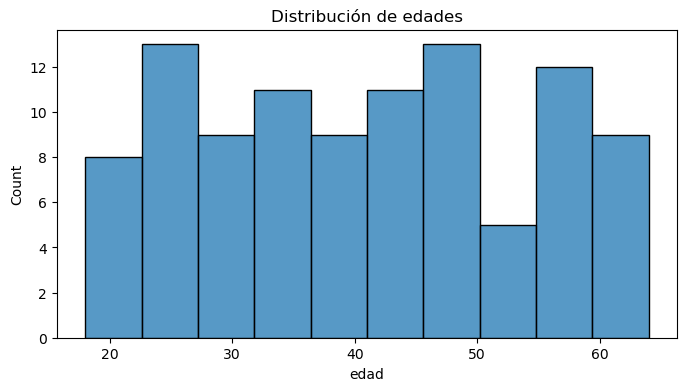

In [37]:
#Distribucion de edades
plt.figure(figsize=(8,4))
sns.histplot(
    df["edad"],
    bins=10
)
plt.title("Distribución de edades")
plt.show()

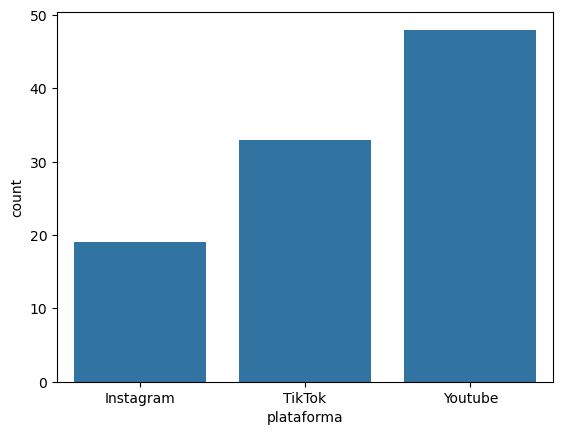

In [39]:
#usuarios por plataforma
sns.countplot(
    x="plataforma",
    data=df
)
plt.show()

In [41]:
#Generamos una copia para contaminarla
df_sucio = df.copy()

In [43]:
#Le colocamos valores nulos
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i, "nombre"] = None

In [45]:
df_sucio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_usuario  100 non-null    int64 
 1   nombre      95 non-null     object
 2   correo      100 non-null    object
 3   edad        100 non-null    int64 
 4   seguidores  100 non-null    int64 
 5   plataforma  100 non-null    object
dtypes: int64(3), object(3)
memory usage: 4.8+ KB


In [47]:
#Edades invalidas
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i,"edad"] = -10

In [49]:
df_sucio.describe()["edad"]

count    100.000000
mean      38.380000
std       16.822772
min      -10.000000
25%       28.000000
50%       39.500000
75%       50.000000
max       63.000000
Name: edad, dtype: float64

In [51]:
#Seguidores imposibles
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc["seguidores"] = 5000000

In [53]:
df_sucio.describe()["seguidores"]

count    1.010000e+02
mean     7.205426e+04
std      4.954554e+05
min      4.140000e+02
25%      1.020800e+04
50%      2.363600e+04
75%      3.437900e+04
max      5.000000e+06
Name: seguidores, dtype: float64

In [57]:
#Generamos correo invalido
for i in random.sample(range(len(df_sucio)),5):
    df_sucio[i,"correo"] = "correo_invalido"

In [63]:
df_sucio.describe(include=["object"])

,nombre,correo,plataforma,"(14, correo)","(33, correo)","(20, correo)","(98, correo)","(13, correo)"
count,96,101,101,101,101,101,101,101
unique,96,101,4,1,1,1,1,1
top,Ing. José María Serrato,raulolivo@example.com,Youtube,correo_invalido,correo_invalido,correo_invalido,correo_invalido,correo_invalido
freq,1,1,48,101,101,101,101,101


In [65]:
df_sucio.isnull().sum()

id_usuario      0
nombre          5
correo          0
edad            0
seguidores      0
plataforma      0
(14, correo)    0
(33, correo)    0
(20, correo)    0
(98, correo)    0
(13, correo)    0
dtype: int64

In [71]:
pd.set_option('display.float_format', lambda x:'%.2f' % x)

In [75]:
#Estadisiticas
df_sucio.describe(include= "all")

,id_usuario,nombre,correo,edad,seguidores,plataforma,"(14, correo)","(33, correo)","(20, correo)","(98, correo)","(13, correo)"
count,101.00,96,101,101.00,101.00,101,101,101,101,101,101
unique,NaN,96,101,NaN,NaN,4,1,1,1,1,1
top,NaN,Ing. José María Serrato,raulolivo@example.com,NaN,NaN,Youtube,correo_invalido,correo_invalido,correo_invalido,correo_invalido,correo_invalido
freq,NaN,1,1,NaN,NaN,48,101,101,101,101,101
mean,49554.95,NaN,NaN,49542.95,72054.26,NaN,NaN,NaN,NaN,NaN,NaN
std,497513.57,NaN,NaN,497514.78,495455.41,NaN,NaN,NaN,NaN,NaN,NaN
min,1.00,NaN,NaN,-10.00,414.00,NaN,NaN,NaN,NaN,NaN,NaN
25%,26.00,NaN,NaN,28.00,10208.00,NaN,NaN,NaN,NaN,NaN,NaN
50%,51.00,NaN,NaN,40.00,23636.00,NaN,NaN,NaN,NaN,NaN,NaN
75%,76.00,NaN,NaN,50.00,34379.00,NaN,NaN,NaN,NaN,NaN,NaN
